# 🔧 Entrenamiento en la Nube con GPU — YOLOv8

**Proyecto:** Detección de defectos en piezas de fundición CNC
**Autor:** Brian Prado — Ingeniería Mecatrónica
**Modelo:** YOLOv8 (Ultralytics) · **Dataset:** casting-detection v10 (Roboflow, 8 clases)

Este notebook entrena el modelo **usando la GPU gratuita de Google Colab**, decenas de veces más rápida que una laptop sin GPU.

---

## ⚠️ PASO 0 — Activar la GPU (¡OBLIGATORIO!)

Antes de ejecutar cualquier celda:

1. Menú **`Entorno de ejecución`** → **`Cambiar tipo de entorno de ejecución`**.
2. En **`Acelerador por hardware`** elige **`GPU T4`**.
3. Pulsa **`Guardar`**.

Si omites este paso, todo correrá en CPU (lento). La siguiente celda confirma si la GPU está activa.

## Paso 1 — Verificar la GPU
Debe aparecer una tabla con una **Tesla T4** (o similar). Si no muestra ninguna GPU, repite el Paso 0.

In [1]:
!nvidia-smi

Thu Jun 18 02:38:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   58C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Paso 2 — Instalar dependencias
Instalamos Ultralytics (YOLOv8) y el cliente de Roboflow. Tarda ~1 minuto.

In [2]:
!pip install -q ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.0 MB/s eta 0:00:00


## Paso 3 — Clonar tu repositorio de GitHub
Descarga tus scripts (`train.py`, `predict.py`, `download_dataset.py`) y la configuración del proyecto.

In [3]:
!git clone https://github.com/BrianPrado-Dev/Vision-Artificial.git
%cd Vision-Artificial

Cloning into 'Vision-Artificial'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 59 (delta 15), reused 52 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 31.89 KiB | 6.38 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/Vision-Artificial


## Paso 4 — Configurar tu API key de Roboflow (de forma segura)
Usamos `getpass` para que tu clave **no quede escrita ni guardada** en el notebook.
Al ejecutar la celda, **pega tu API key** en el cuadro que aparece y presiona Enter.
> ¿Dónde está tu key? En https://app.roboflow.com → Settings → API Keys.

In [4]:
import os
from getpass import getpass

os.environ["ROBOFLOW_API_KEY"] = getpass("Pega tu API key de Roboflow y presiona Enter: ")
print("✅ API key configurada en esta sesión (no se guarda en el notebook).")

Pega tu API key de Roboflow y presiona Enter: ··········
✅ API key configurada en esta sesión (no se guarda en el notebook).


## Paso 5 — Descargar el dataset desde Roboflow
Tu script `download_dataset.py` toma la API key del paso anterior, descarga el dataset
y **corrige automáticamente las rutas** del `data.yaml` para que YOLO lo encuentre.

In [5]:
!python scripts/download_dataset.py

 DESCARGA DE DATASET PÚBLICO - Roboflow Universe
[INFO] Workspace : new-workspace-kmz9b
[INFO] Proyecto  : casting-detection-leboi
[INFO] Formato   : yolov8
[INFO] Destino   : /content/Vision-Artificial/datasets/roboflow_fundicion

loading Roboflow workspace...
loading Roboflow project...
[INFO] Versión más reciente detectada automáticamente: v10

[INFO] Descargando dataset (v10) en formato 'yolov8'...

Extracting Dataset Version Zip to datasets/roboflow_fundicion in yolov8:: 100% 8552/8552 [00:01<00:00, 8407.55it/s] 
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[INFO] data.yaml corregido con ruta absoluta: /content/Vision-Artificial/datasets/roboflow_fundicion

----- CONTENIDO DEL DATASET DESCARGADO -----
  Archivo de confi

## Paso 6 — Entrenar el modelo con GPU 🚀
Parámetros usados:
- `--model yolov8s.pt` → versión *small* (buen balance precisión/velocidad en GPU).
- `--epochs 50` → 50 pasadas al dataset (sube a 100 para más precisión).
- `--imgsz 640` → resolución de entrenamiento.
- `--batch 16` → imágenes por lote (la T4 lo soporta bien).
- `--device 0` → usa la **GPU**.

⏱️ En una T4, ~50 épocas suelen tardar **1–3 horas**. Mantén la pestaña abierta.

In [11]:
!python scripts/train.py --data datasets/roboflow_fundicion/data.yaml --model yolov8s.pt --epochs 50 --imgsz 640 --batch 16 --device 0 --workers 2

 INICIO DEL ENTRENAMIENTO - YOLOv8 (Detección de defectos CNC)
[INFO] Archivo de dataset encontrado: /content/Vision-Artificial/datasets/roboflow_fundicion/data.yaml
[INFO] Dispositivo seleccionado manualmente: 0
[INFO] Cargando modelo base: yolov8s.pt

----- CONFIGURACIÓN DEL ENTRENAMIENTO -----
  Dataset      : datasets/roboflow_fundicion/data.yaml
  Modelo base  : yolov8s.pt
  Épocas       : 50
  Tamaño imagen: 640 px
  Batch size   : 16
  Dispositivo  : 0
-------------------------------------------

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/roboflow_fundicion/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.

## Paso 7 — Visualizar métricas del entrenamiento
Mostramos las gráficas que YOLO genera solo: curvas de pérdida/precisión, matriz de
confusión y curva Precisión-Recall. Son excelentes evidencias para tu informe.

📁 Resultados encontrados en: runs/detect/runs/entrenamiento/defectos_yolov8-2

===== results.png =====


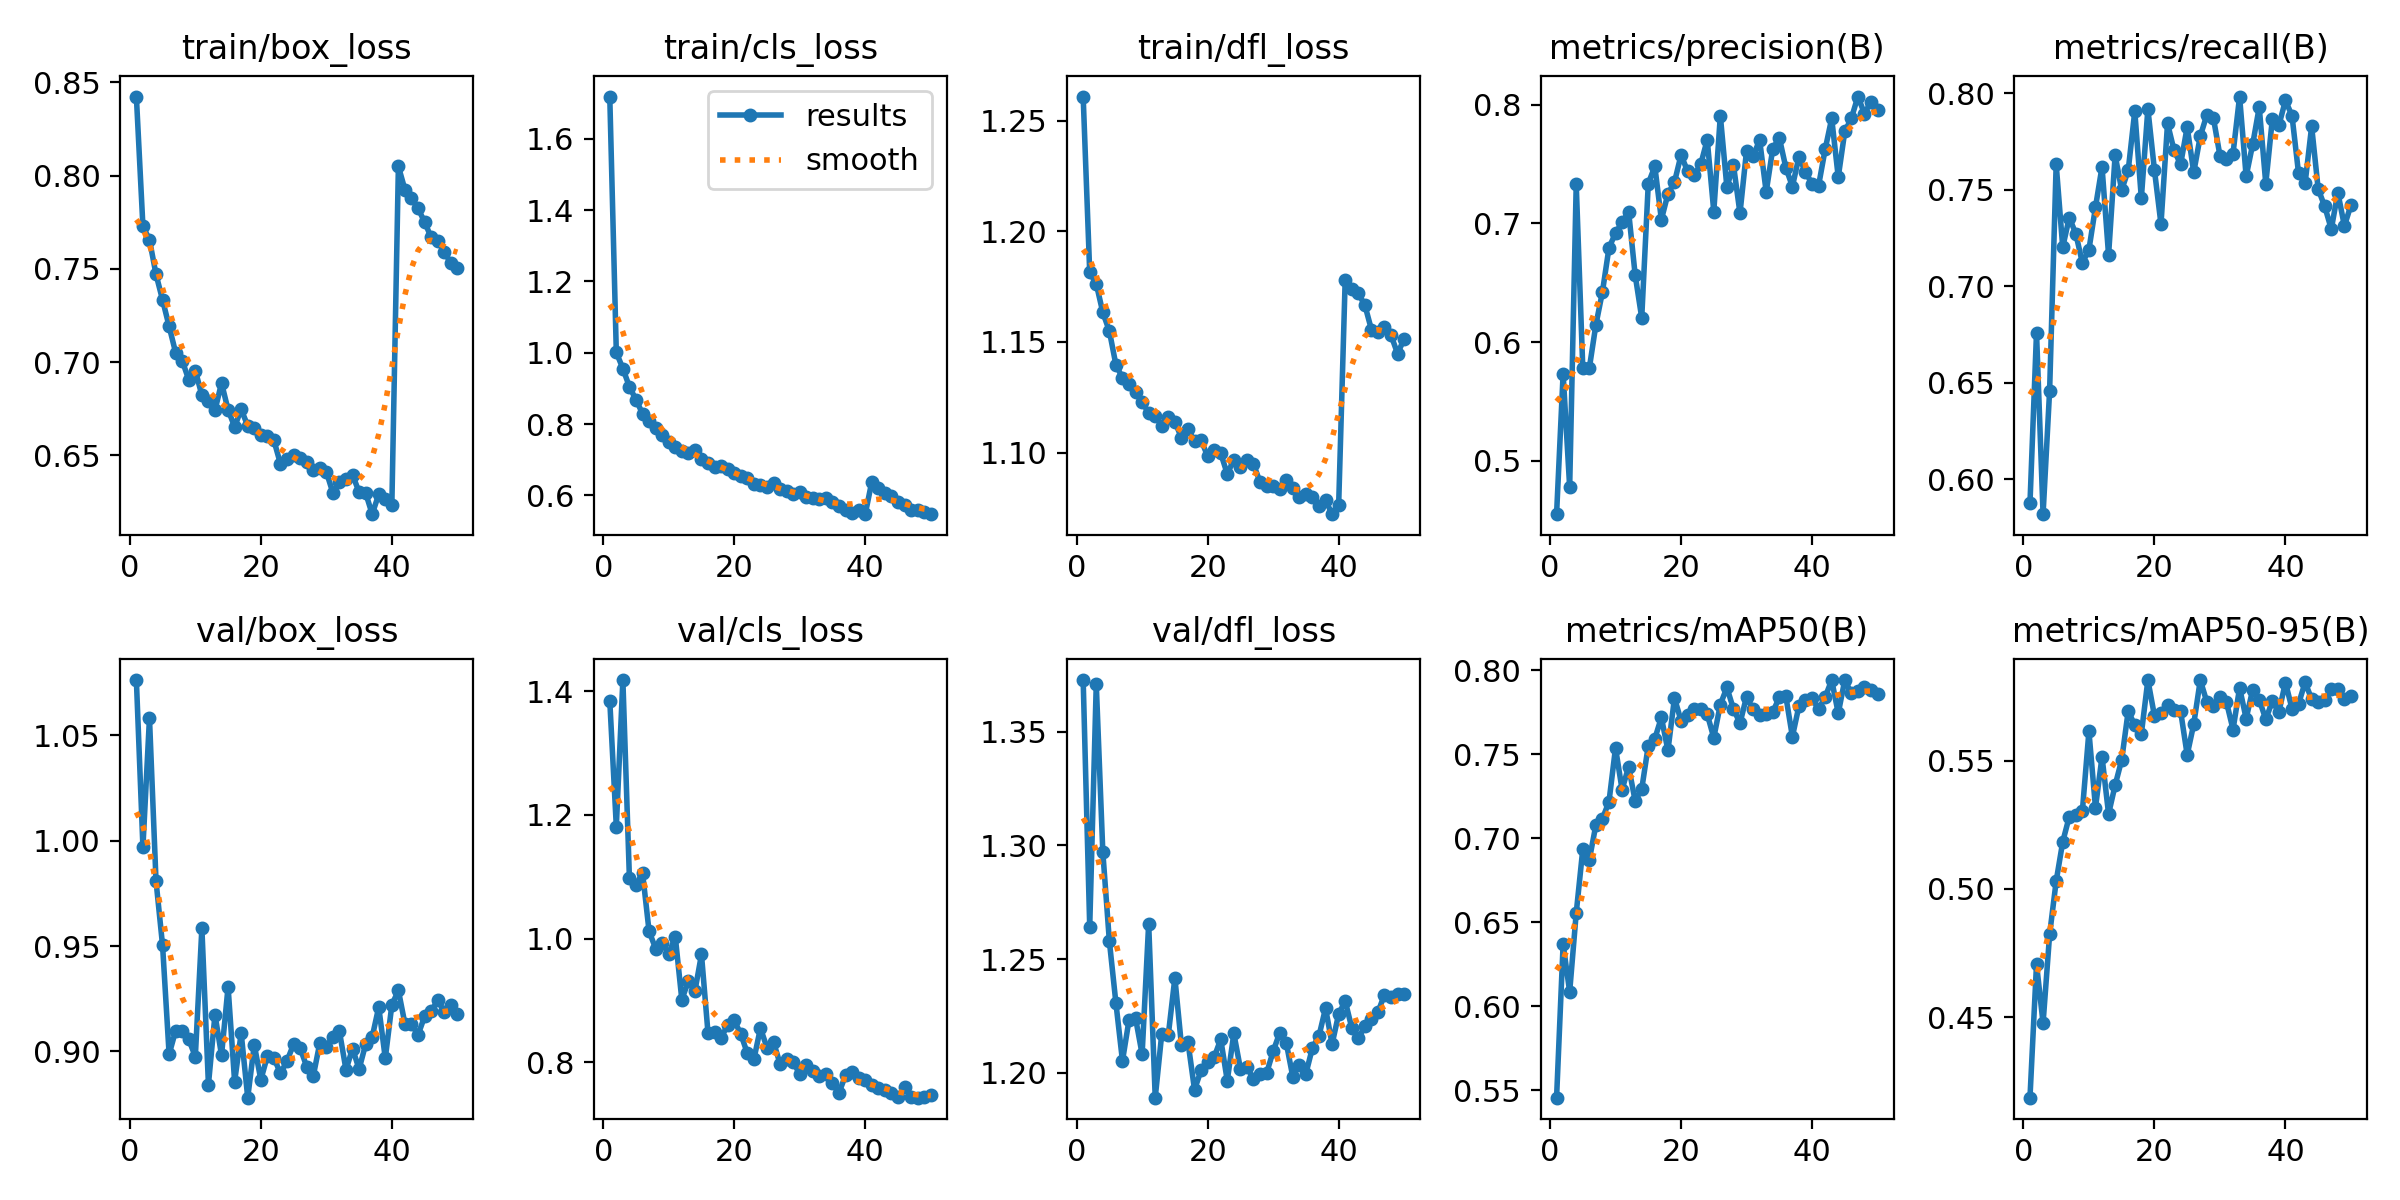


===== confusion_matrix.png =====


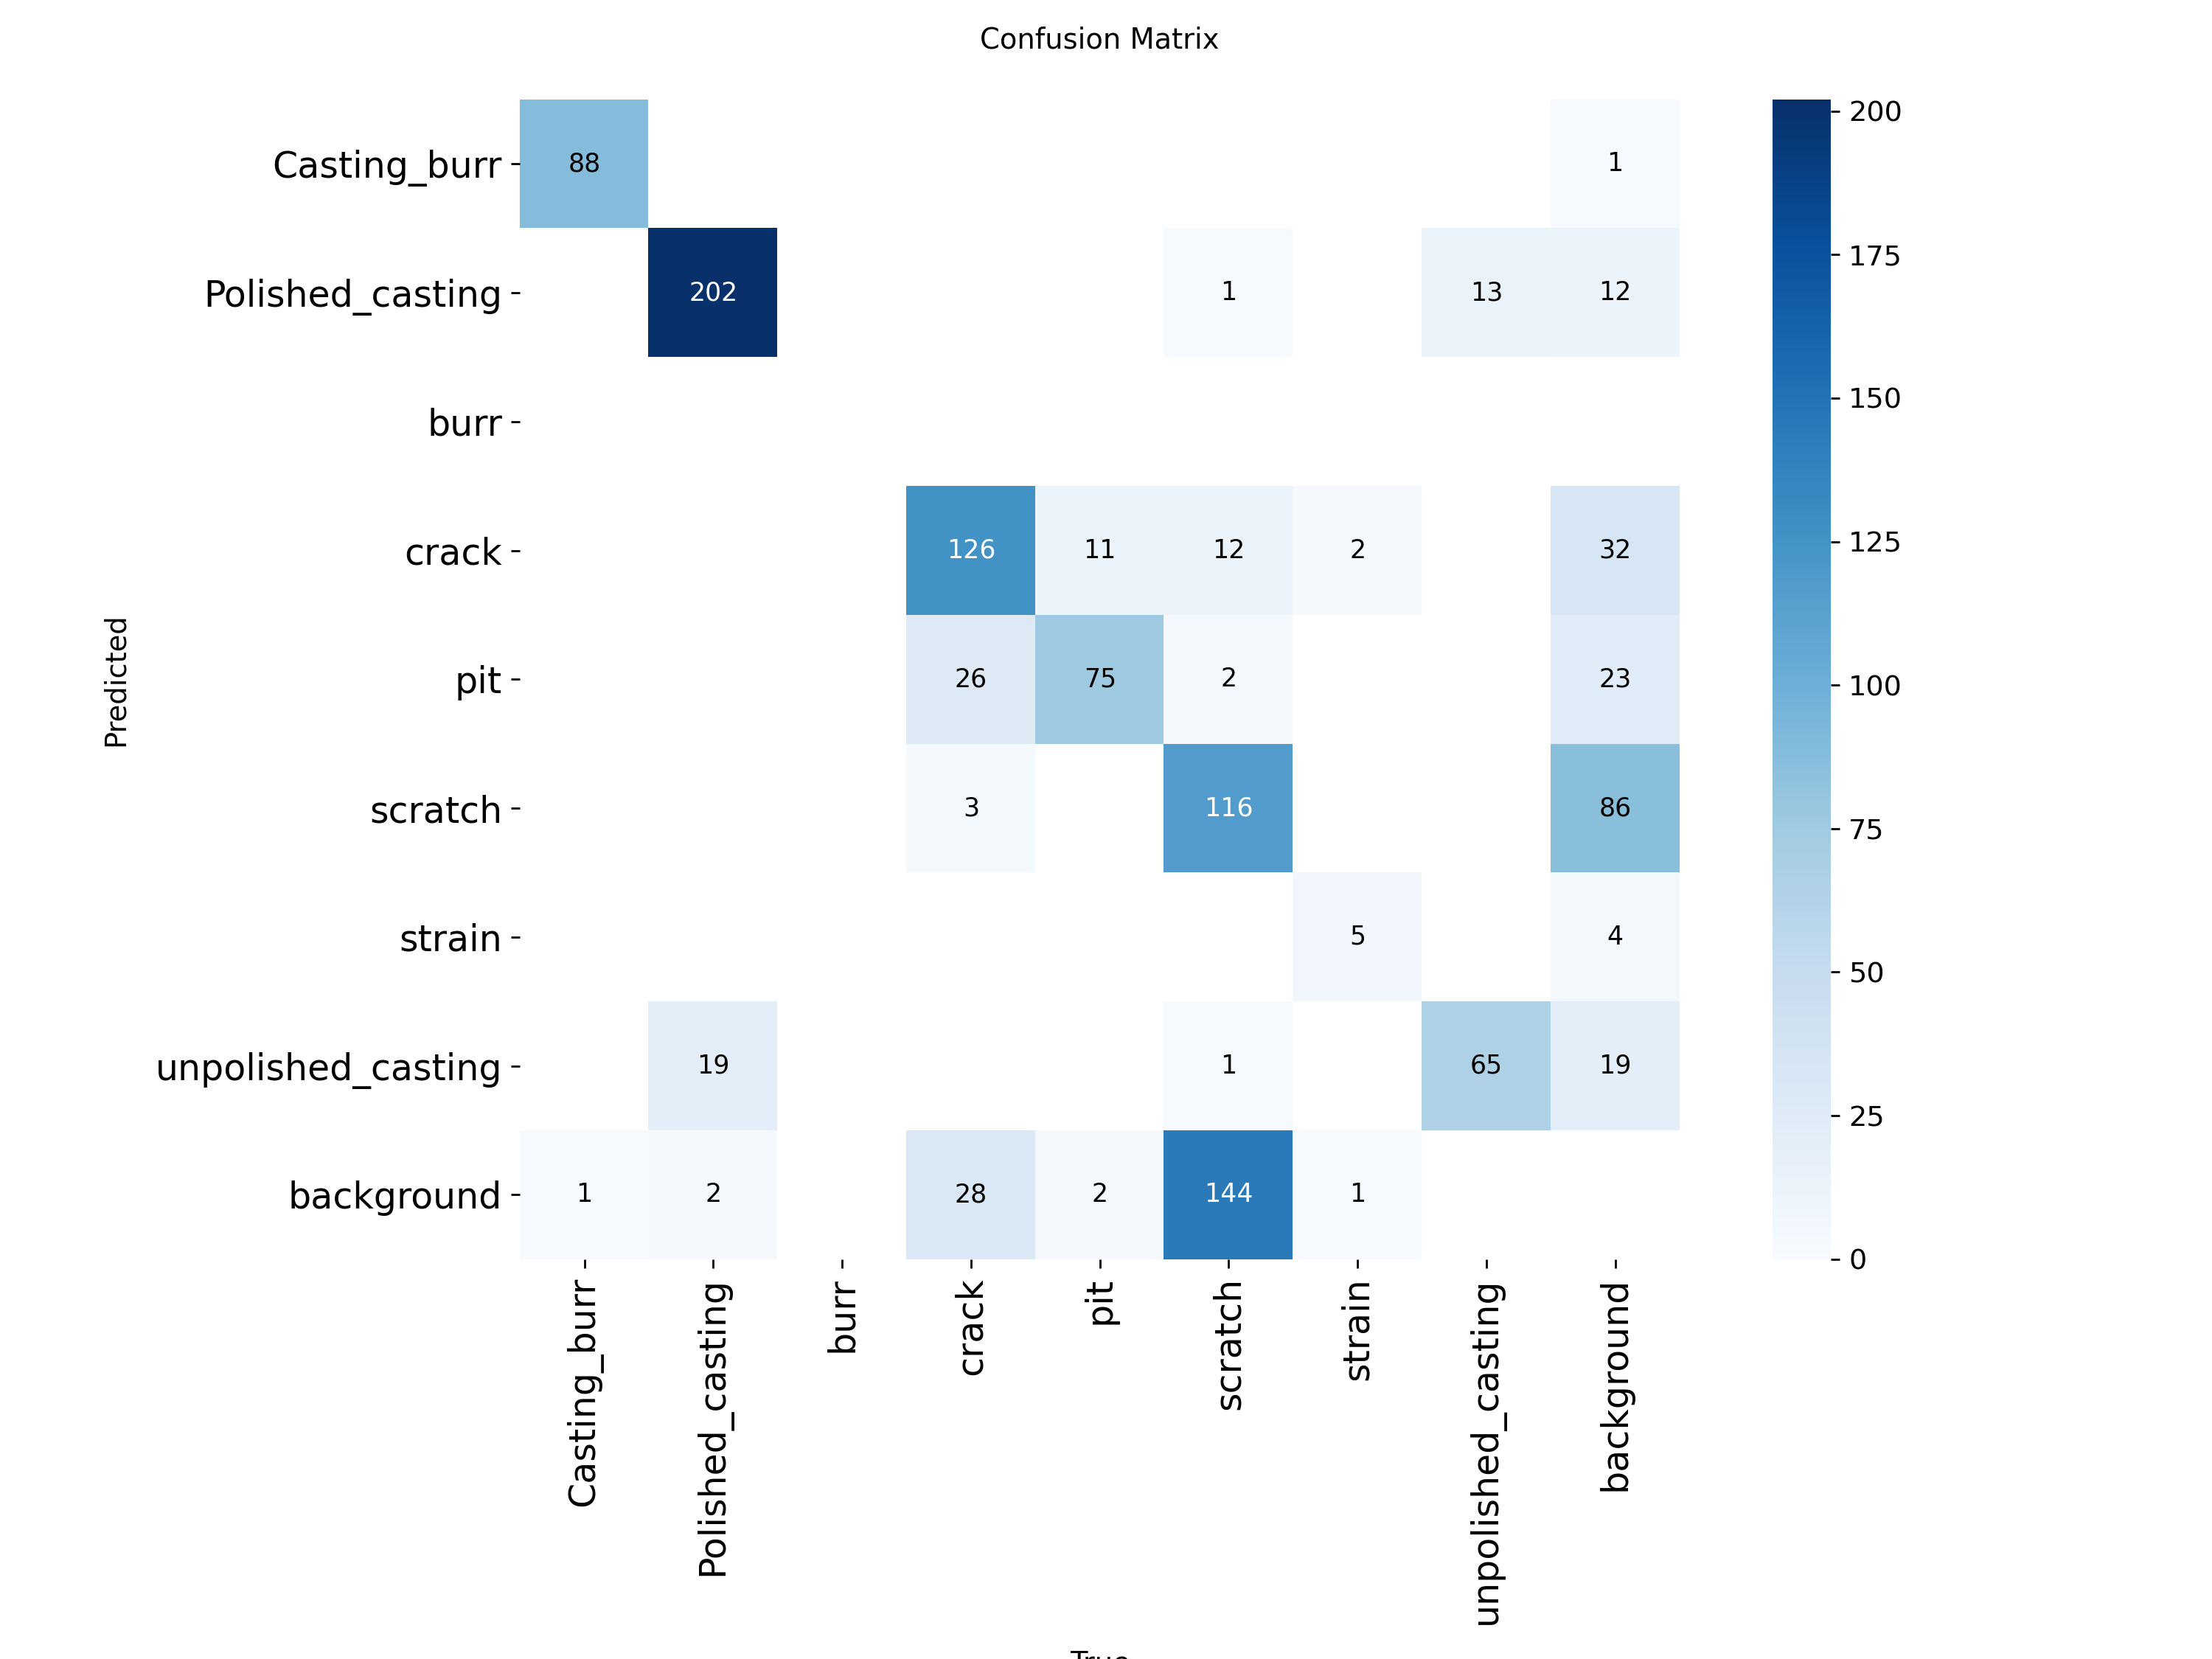

In [12]:
import glob, os
from IPython.display import Image, display

# Busca cualquier entrenamiento COMPLETADO (best.pt solo existe al terminar)
pesos = sorted(glob.glob('runs/**/weights/best.pt', recursive=True), key=os.path.getmtime)

if not pesos:
    print("⚠️  No se encontró ningún entrenamiento completado en 'runs/'.")
    print("    Revisa que el PASO 6 haya terminado SIN errores (debe decir 'Results saved to ...').")
    print("    Si tu GPU no estaba activa, actívala (Paso 0) y re-ejecuta desde el Paso 2.")
else:
    run_dir = os.path.dirname(os.path.dirname(pesos[-1]))   # .../weights/best.pt -> carpeta del run
    print("📁 Resultados encontrados en:", run_dir)
    for nombre in ['results.png', 'confusion_matrix.png', 'PR_curve.png']:
        ruta = os.path.join(run_dir, nombre)
        if os.path.exists(ruta):
            print("\n===== " + nombre + " =====")
            display(Image(filename=ruta))

## Paso 8 — Ver predicciones sobre imágenes de validación
YOLO guarda lotes de validación con las cajas predichas: útil para ver "qué tan bien ve".

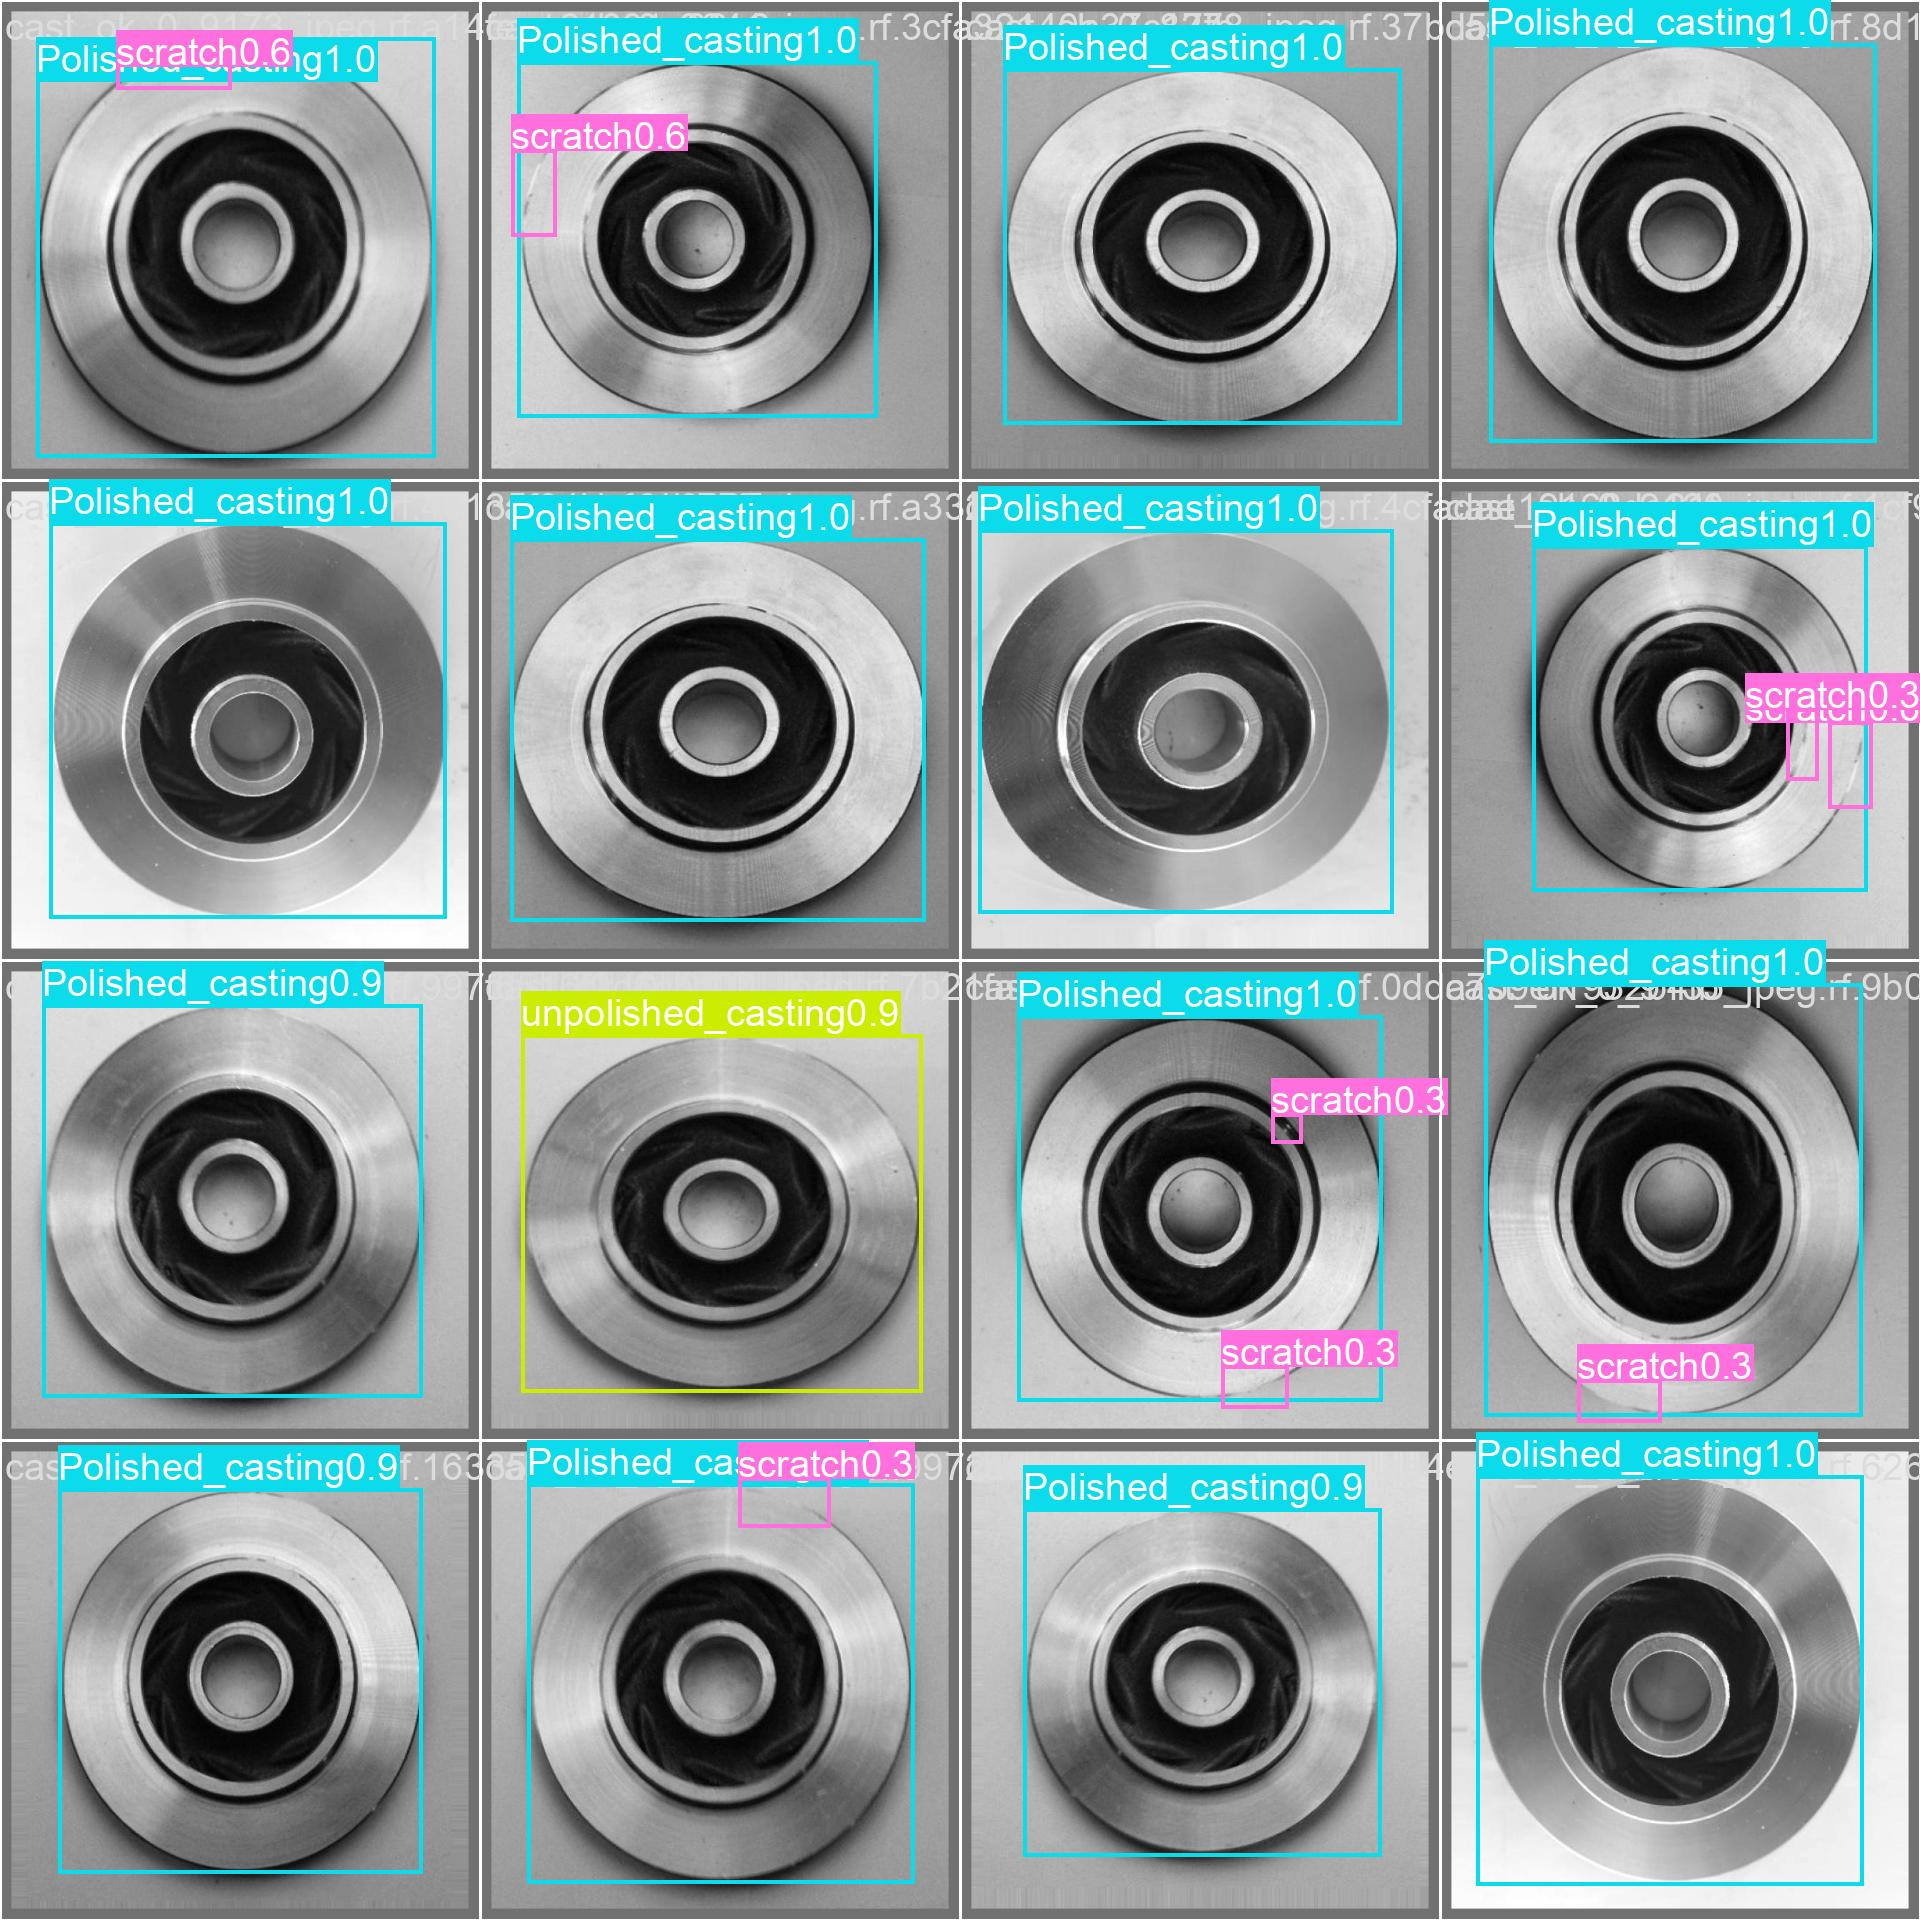

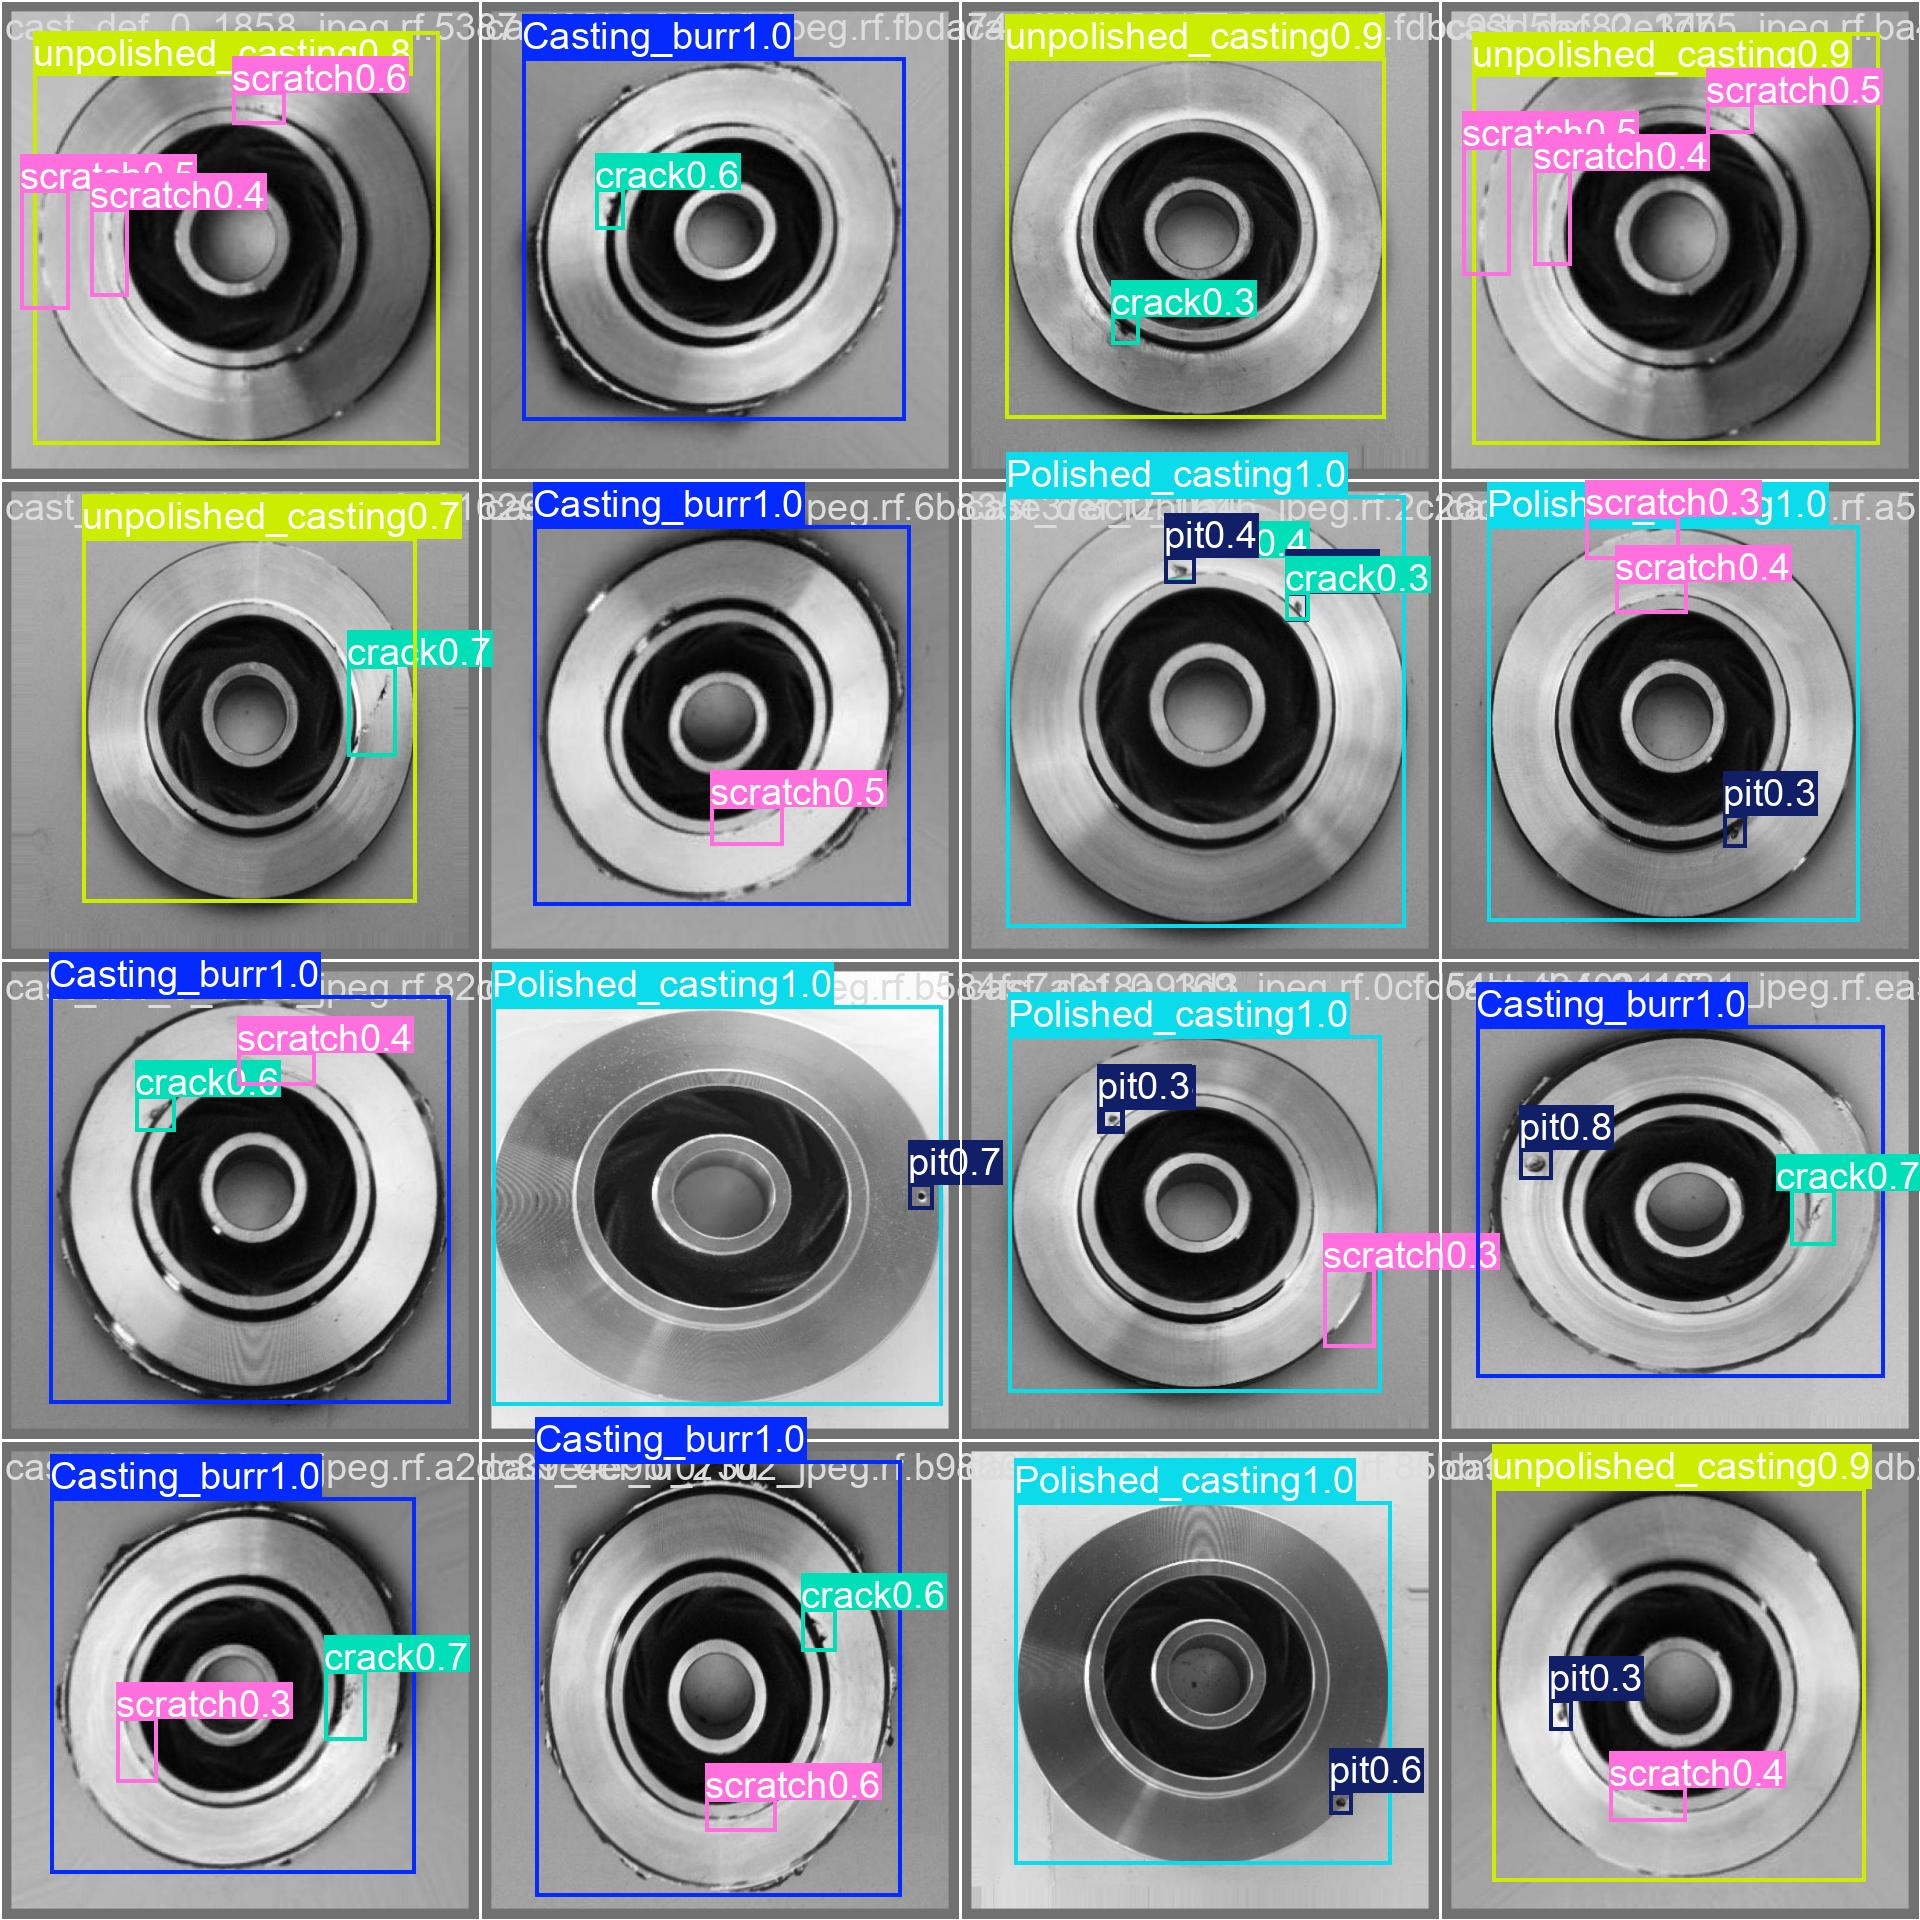

In [13]:
for nombre in ['val_batch0_pred.jpg', 'val_batch1_pred.jpg']:
    ruta = os.path.join(run_dir, nombre)
    if os.path.exists(ruta):
        display(Image(filename=ruta))

## Paso 9 — Inferencia sobre el conjunto de PRUEBA (test)
Ejecutamos tu `predict.py` con el mejor modelo (`best.pt`) sobre las imágenes de prueba
y mostramos algunos resultados con sus *bounding boxes*.

In [16]:
!python scripts/predict.py --model {run_dir}/weights/best.pt --source datasets/roboflow_fundicion/test/images --conf 0.25

import glob, os
from IPython.display import Image, display

# predict.py YA guardó las imágenes anotadas aquí (lo confirma su mensaje de salida).
carpeta = 'evidencias/predicciones'
imagenes = sorted(glob.glob(os.path.join(carpeta, '*.jpg')) +
                  glob.glob(os.path.join(carpeta, '*.png')))

# Plan B: si no aparecieran, buscar en cualquier subcarpeta de evidencias/
if not imagenes:
    imagenes = sorted(glob.glob('evidencias/**/*.jpg', recursive=True) +
                      glob.glob('evidencias/**/*.png', recursive=True))

print(f"Imágenes de predicción encontradas: {len(imagenes)}")
for p in imagenes[:6]:
    print("  ", p)
    display(Image(filename=p))

 INICIO DE LA INFERENCIA - YOLOv8 (Detección de defectos CNC)
[INFO] Modelo encontrado: /content/Vision-Artificial/runs/detect/runs/entrenamiento/defectos_yolov8-2/weights/best.pt
[INFO] Cargando modelo entrenado: runs/detect/runs/entrenamiento/defectos_yolov8-2/weights/best.pt

----- CONFIGURACIÓN DE LA INFERENCIA -----
  Fuente       : datasets/roboflow_fundicion/test/images
  Confianza min: 0.25
  Dispositivo  : 0
  Salida       : evidencias/predicciones
------------------------------------------


image 1/220 /content/Vision-Artificial/datasets/roboflow_fundicion/test/images/cast_def_0_1019_jpeg.rf.c96a3513d835c3d9bedd9c2dbd697f61.jpg: 640x640 1 pit, 1 unpolished_casting, 14.9ms
image 2/220 /content/Vision-Artificial/datasets/roboflow_fundicion/test/images/cast_def_0_1113_jpeg.rf.2dd8688dda55d05b844465874dad7546.jpg: 640x640 2 cracks, 1 pit, 1 scratch, 1 unpolished_casting, 14.9ms
image 3/220 /content/Vision-Artificial/datasets/roboflow_fundicion/test/images/cast_def_0_1115_jpeg.rf

In [17]:
import glob, os
from IPython.display import Image, display

# 1) Ver qué generó YOLO dentro de runs/
print("Contenido de runs/:")
for p in sorted(glob.glob('runs/*/*')):
    print("   ", p)

# 2) Buscar la carpeta con las imágenes anotadas
candidatas = [c for c in (glob.glob('runs/detect/*') +
                          glob.glob('runs/**/predict*', recursive=True) +
                          glob.glob('evidencias/*')) if os.path.isdir(c)]

carpeta_imgs = None
for c in candidatas:
    n = len(glob.glob(os.path.join(c, '*.jpg')))
    if n:
        print(f"\n✅ {n} imágenes anotadas encontradas en: {c}")
        carpeta_imgs = c

# 3) Mostrar 6 ejemplos
if carpeta_imgs:
    for p in sorted(glob.glob(os.path.join(carpeta_imgs, '*.jpg')))[:6]:
        display(Image(filename=p))
else:
    print("\n⚠️ No aparecieron. Ejecuta en una celda:  !ls -R runs evidencias")

Contenido de runs/:
    runs/detect/evidencias
    runs/detect/runs

⚠️ No aparecieron. Ejecuta en una celda:  !ls -R runs evidencias


## Paso 10 — Descargar el modelo entrenado (`best.pt`)
Descarga el archivo a tu PC y colócalo en la carpeta **`models/`** de tu proyecto local
para usarlo con `predict.py`.

In [18]:
from google.colab import files
print("Se descargará best.pt. Guárdalo en la carpeta models/ de tu proyecto.")
files.download(f"{run_dir}/weights/best.pt")

Se descargará best.pt. Guárdalo en la carpeta models/ de tu proyecto.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## (Opcional) Paso 11 — Guardar TODO en tu Google Drive
Copia la carpeta completa de resultados (pesos + gráficas) a tu Drive, por si Colab se desconecta.

In [19]:
from google.colab import drive
drive.mount('/content/drive')
!cp -r {run_dir} /content/drive/MyDrive/
print("✅ Resultados copiados a Google Drive (MyDrive).")

Mounted at /content/drive
✅ Resultados copiados a Google Drive (MyDrive).


---
## ✅ Siguientes pasos y consejos

- **Guarda evidencias** para tu informe: descarga `results.png`, `confusion_matrix.png` y algunas predicciones.
- **Sube `best.pt` a tu repo**: colócalo en `models/` y haz commit/push (pesa ~22 MB).
- **¿Más precisión?** Aumenta `--epochs` a 100–150 o usa `--model yolov8m.pt`.
- **Las 8 clases del dataset:** `Casting_burr`, `Polished_casting`, `burr`, `crack`, `pit`, `scratch`, `strain`, `unpolished_casting`.
- **Colab se desconecta** tras inactividad; mantén la pestaña abierta durante el entrenamiento.

> 💡 Tip: si Colab limita la GPU, reduce `--epochs` o `--imgsz` (p. ej. 416).